# Heart Disease Prediction 

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Heart Disease UCI dataset. This includes:

- Loading the dataset
- Understanding the dataset structure
- Identifying missing values
- Cleaning the data
- Exploring feature distributions
- Studying relationships among variables
- Preparing the dataset for model development

---

**Dataset:** Heart Disease UCI Dataset

**Author:** Piyush Bhide

## Step 1: Import Required Libraries

In [517]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Set project paths

In [518]:

from pathlib import Path
#helps us create file paths

In [519]:
PROJECT_ROOT = Path("..").resolve()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

#RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
#PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Processed data folder:", PROCESSED_DATA_DIR)

Project root: D:\MLOps\heart-disease-mlops
Raw data folder: D:\MLOps\heart-disease-mlops\data\raw
Processed data folder: D:\MLOps\heart-disease-mlops\data\processed


## Step 3: Downloading the Data
>Run pip install ucimlrepo in terminal

In [520]:
#Import the package
from ucimlrepo import fetch_ucirepo

import pandas as pd

# Fetch the Heart Disease dataset in the UCI repository with a unique ID.
# Heart Disease Dataset → 45

heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features # X contains all the input features.
y = heart_disease.data.targets  #y contains the target column.

#Combine them into one DataFrame

df = pd.concat([X, y], axis=1)

#Display the first few rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [521]:
df.shape

(303, 14)

In [522]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

now we will save the data to a .csv file so that the same can be reffered later
this will ensure the reproducebility

In [523]:
df.to_csv("../data/raw/heart.csv", index=False)

print("Dataset saved successfully.")


Dataset saved successfully.


In [524]:
df.info()
#Return > No of columns , Column names, Data Type, Missing Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Column 11 ca Has missing values 
 - 299 in place of 303, 
 - 4 values missing

Column 12 thal has missing values, 
 - 301 in place of 303, 
 - 2 values missing

Total 6 values missing

In [525]:
df.describe()
#return Count, Mean, Standard Deviation , minimum, Quartiles, maximum

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [526]:
df.columns
#return column names

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

first rename the target column name from num to target

In [527]:
df.rename(columns={"num": "target"}, inplace=True)

In [528]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [529]:
#update the heart.csv after renaming the colume
from pathlib import Path

output_path = Path("../data/raw/heart.csv")

df.to_csv(output_path, index=False)

print(f"Dataset saved successfully to:\n{output_path}")

Dataset saved successfully to:
..\data\raw\heart.csv


## Step 4: Exploratory Data Analysis (EDA)

In [530]:
# Check the number of missing values in each column
df.isnull().sum() 
# isnull to check missing value, 
# return true if value is missing,
# .sum counts no of true cells

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

 - ca      4
 - thal    2
 - This means:

 - 4 patients do not have a value for the ca feature.
 - 2 patients do not have a value for the thal feature.

 - All other columns have complete data.

In [531]:
# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.320132
thal        0.660066
target      0.000000
dtype: float64

# Step 4.1 Visualize Missing Values

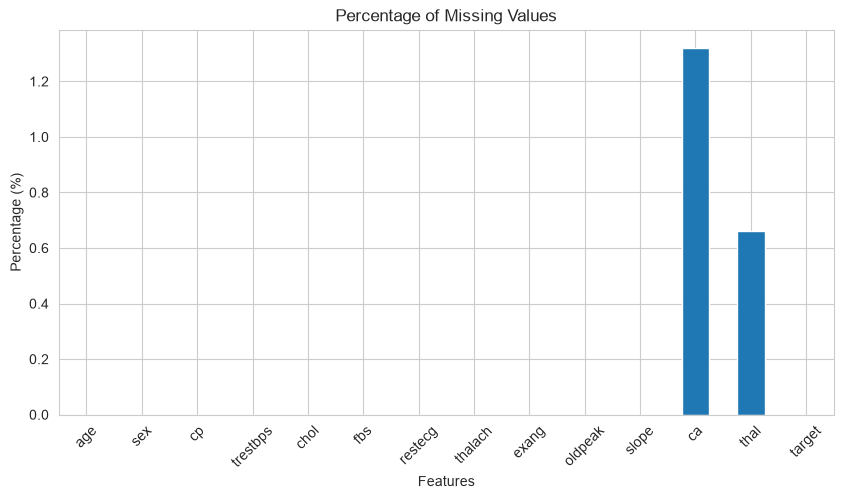

In [532]:
plt.figure(figsize=(10, 5))

missing_percentage.plot(kind="bar")

plt.title("Percentage of Missing Values")
plt.xlabel("Features")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)

plt.show()

In [533]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


# Step 4.2 Handle Missing Values

In [534]:
# Fill missing values with the most frequent value (mode)

df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

In [535]:
#Verify the Missing Values Are Gone
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Step 4.3 Convert to Binary Target

The Target column is still not binary target, it has 0-4 count

In [536]:
df["target"].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [537]:
# Convert target to binary
# 0 = No heart disease
# 1 = Heart disease present

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

In [538]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

0 means no heart disease
1 Heart disease present

# Step 4.4 Check for Duplicate Records

In [539]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

# Step 4.5 Class Distribution
Count the class for target, 

In [540]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

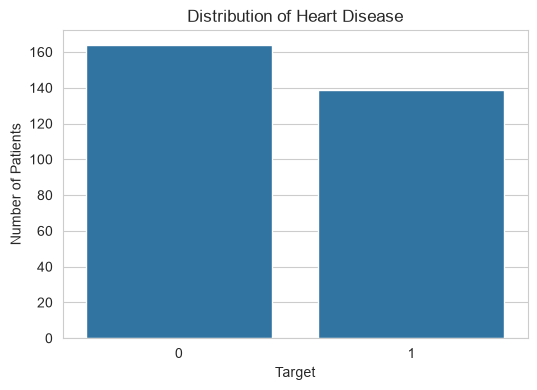

In [541]:
plt.figure(figsize=(6, 4))

sns.countplot(x="target", data=df)

plt.title("Distribution of Heart Disease")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.show()

"The target variable is reasonably balanced, with a comparable number of patients in both classes. Therefore, no additional balancing techniques (such as oversampling or undersampling) are required before model training."

# Step 4.6 Histograms (Feature Distribution)

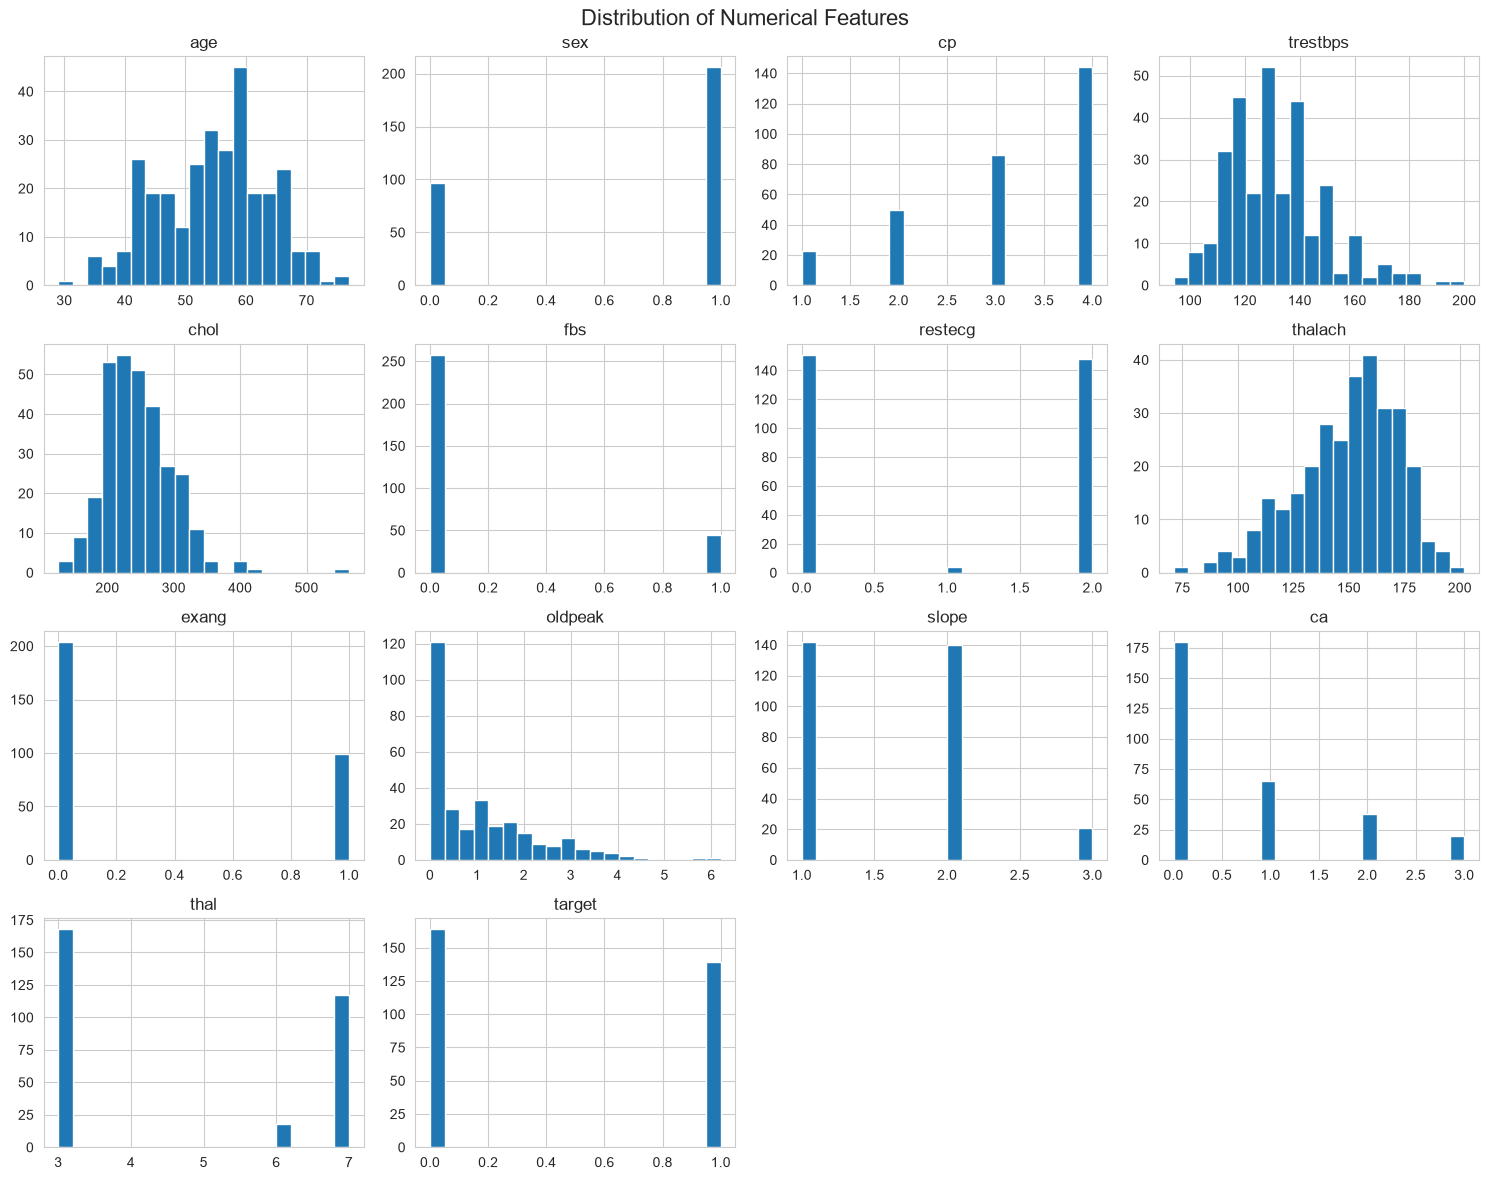

In [542]:
# Plot histograms for all numerical features

df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

| Feature        | Observation                                                           |
| -------------- | ----------------------------------------------------------------------|
| Age            | Mostly 50–60 years                                                    |
| Sex            | More males than females                                               |
| CP             | not equally represented,CP type may be an important predictor disease |
| trestbps       | Most observations lie in a reasonable clinical range                  |
| Cholesterol    | Right-skewed with a few high values                                   |
| Blood Pressure | trestbps Mostly 110–140 mmHg                                          |
| Resting ECG    | restecg categorical feature with an uneven distribution               |
| Slope          | Categories 1 and 2 dominate the dataset                               |
| ca             | The feature is highly imbalanced across categories                    |
| Thalach        | Approximately bell-shaped                                             |
| Oldpeak        | Right-skewed                                                          |
| FBS            | Mostly 0                                                              |
| Exang          | Mostly 0                                                              |
| Target         | Balanced classes                                                      |


Histograms were generated for all numerical and encoded categorical variables. The age distribution indicates that most patients are middle-aged to older adults. Cholesterol and oldpeak show right-skewed distributions with a few high values. Binary variables such as sex, fasting blood sugar, and exercise-induced angina are dominated by one category. The target variable is reasonably balanced, making the dataset suitable for binary classification without applying class balancing techniques.

# Step 4.6 Correlation Heatmap

Calculate the Correlation Matrix

In [543]:
# Calculate correlation matrix
correlation_matrix = df.corr()

correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.128303,0.223120
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.380581,0.276816
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233117,0.262089,0.414446
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.134424,0.150825
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.018351,0.085164
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.064625,0.025264
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.024325,0.169202
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.274142,-0.417167
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.325240,0.431894
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.342405,0.424510


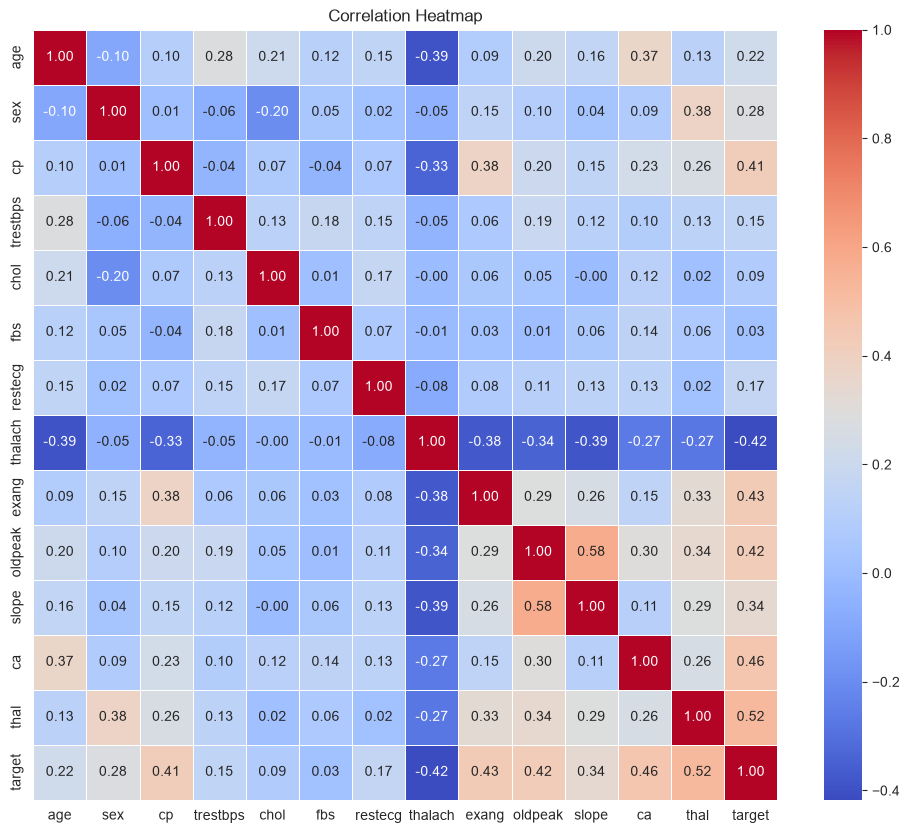

In [544]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()